In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Сделаем предобработку данных
Уже сделали заранее в других файлах

In [14]:
df_volume = pd.read_csv('volume.csv')


In [15]:
df_volume['date'] = df_volume['begin'].str.split(' ').str[0]
df_volume['time'] = df_volume['begin'].str.split(' ').str[1]


In [16]:
df_volume['date'] = pd.to_datetime(df_volume['date'])
df_volume = df_volume[df_volume['date'].dt.dayofweek < 5].copy()

In [17]:
ASSET = 'BR'
df_volume_asset = df_volume[df_volume['ASSETCODE']== ASSET]
df_volume_asset

,ASSETCODE,begin,volume,date,time
28452,BR,2025-04-01 08:00:00,177,2025-04-01,08:00:00
28453,BR,2025-04-01 09:00:00,14151,2025-04-01,09:00:00
28454,BR,2025-04-01 10:00:00,15977,2025-04-01,10:00:00
28455,BR,2025-04-01 11:00:00,18272,2025-04-01,11:00:00
28456,BR,2025-04-01 12:00:00,16338,2025-04-01,12:00:00
...,...,...,...,...,...
31828,BR,2025-12-30 19:00:00,11575,2025-12-30,19:00:00
31829,BR,2025-12-30 20:00:00,6345,2025-12-30,20:00:00
31830,BR,2025-12-30 21:00:00,4148,2025-12-30,21:00:00
31831,BR,2025-12-30 22:00:00,6140,2025-12-30,22:00:00


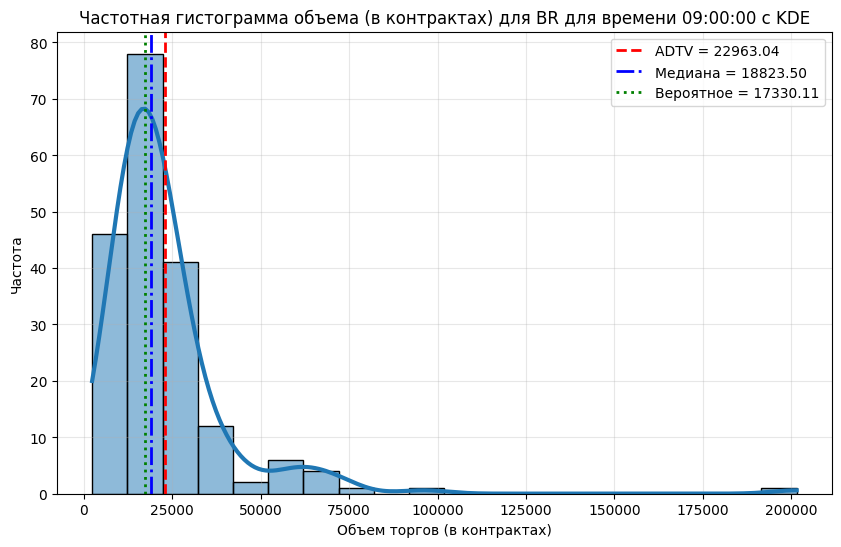

In [18]:
TIME = '09:00:00'
df_time = df_volume_asset[df_volume_asset['time'] == TIME]


adtv_value = df_time['volume'].mean()
median_value = df_time['volume'].median()

plt.figure(figsize=(10, 6))
ax = sns.histplot(data=df_time, x='volume', kde=True, bins=20, 
                  line_kws={'linewidth': 3, 'color': 'red'})

kde_line = ax.lines[0]  
x_kde = kde_line.get_xdata()
y_kde = kde_line.get_ydata()
peak_value = x_kde[y_kde.argmax()]  

plt.title(f'Частотная гистограмма объема (в контрактах) для {ASSET} для времени {TIME} с KDE')

plt.axvline(x=adtv_value, color='red', linestyle='--', linewidth=2, 
            label=f'ADTV = {adtv_value:.2f}')
plt.axvline(x=median_value, color='blue', linestyle='-.', linewidth=2, 
            label=f'Медиана = {median_value:.2f}')
plt.axvline(x=peak_value, color='green', linestyle=':', linewidth=2, 
            label=f'Вероятное = {peak_value:.2f}')

plt.xlabel('Объем торгов (в контрактах)')
plt.ylabel('Частота')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Проверка распределения


NORM: μ=22963.04, σ=19344.95


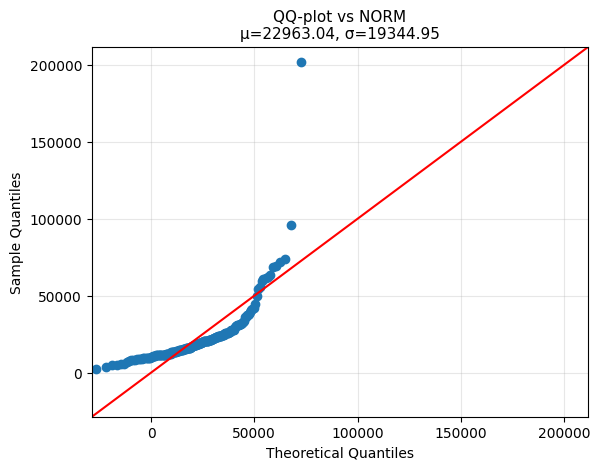


GAMMA: shape a=2.70, scale=8500.58


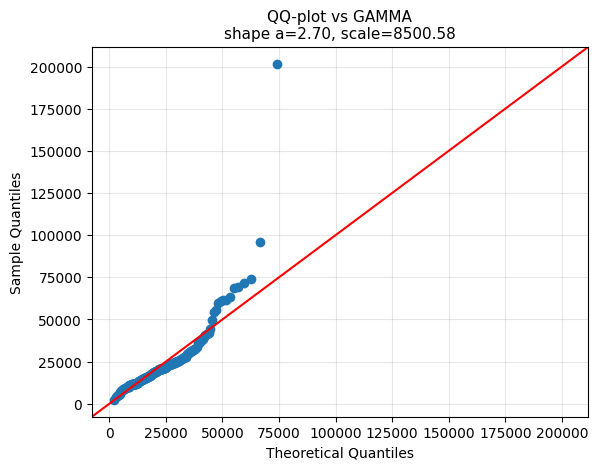


EXPON: λ=0.0000, scale=20650.04


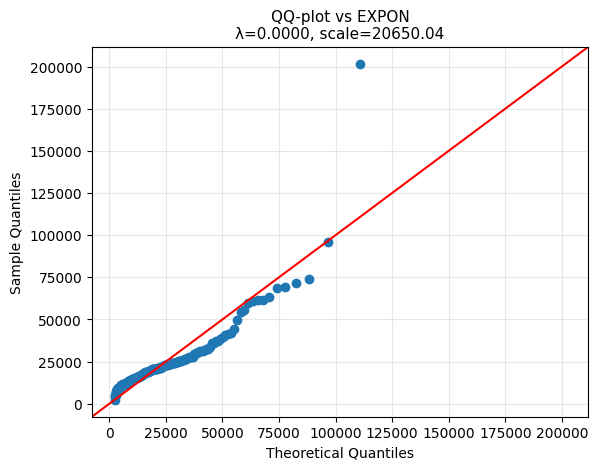


T: df=1.81, loc=17516.59, scale=6669.68


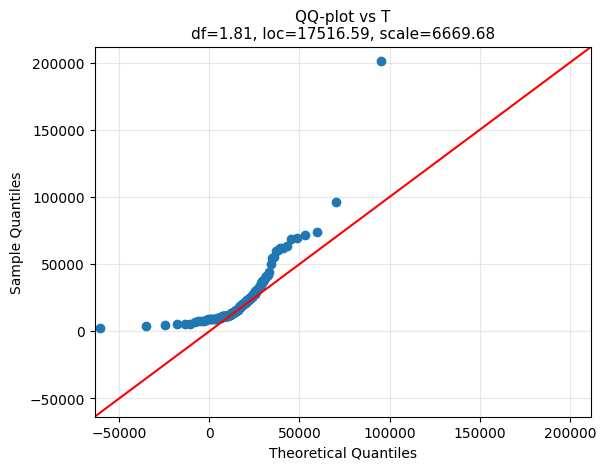


LOGNORM: shape s=0.59, scale=18974.02


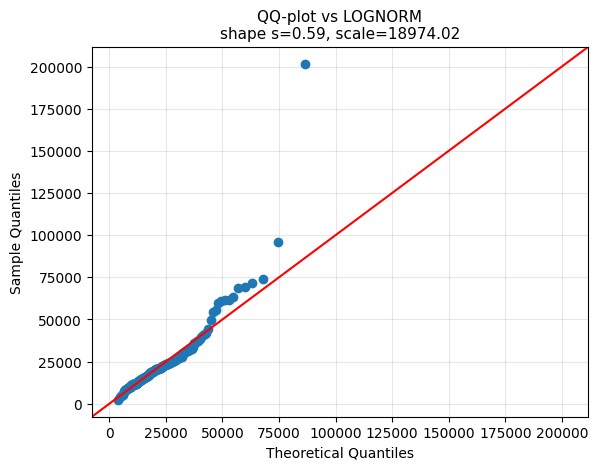


WEIBULL_MIN: shape c=1.45, scale=25634.53


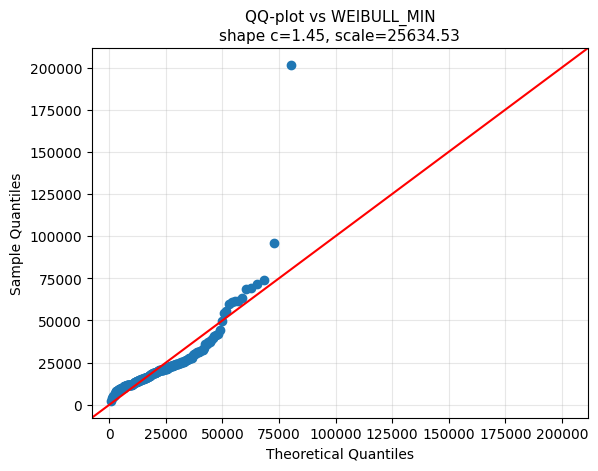

In [19]:
import scipy.stats as stats
import statsmodels.api as sm
import matplotlib.pyplot as plt
import numpy as np

data = df_time['volume'].values

for dist_name in ['norm', 'gamma', 'expon', 't', 'lognorm', 'weibull_min']:
    try:
        dist = getattr(stats, dist_name)
        
        # Подгонка MLE параметров
        if dist_name == 'gamma':
            a, loc, scale = dist.fit(data, floc=0) 
            params_text = f"shape a={a:.2f}, scale={scale:.2f}"
            fig = sm.qqplot(data, dist=dist, distargs=(a,), loc=loc, scale=scale, line='45')
            
        elif dist_name == 't':
            df, loc, scale = dist.fit(data) 
            params_text = f"df={df:.2f}, loc={loc:.2f}, scale={scale:.2f}"
            fig = sm.qqplot(data, dist=dist, distargs=(df,), loc=loc, scale=scale, line='45')
            
        elif dist_name == 'lognorm':
            s, loc, scale = dist.fit(data) 
            params_text = f"shape s={s:.2f}, scale={scale:.2f}"
            fig = sm.qqplot(data, dist=dist, distargs=(s,), loc=loc, scale=scale, line='45')
            
        elif dist_name == 'weibull_min':
            c, loc, scale = dist.fit(data, floc=0) 
            params_text = f"shape c={c:.2f}, scale={scale:.2f}"
            fig = sm.qqplot(data, dist=dist, distargs=(c,), loc=loc, scale=scale, line='45')
            
        else:  # norm, expon
            loc, scale = dist.fit(data) 
            if dist_name == 'norm':
                params_text = f"μ={loc:.2f}, σ={scale:.2f}"
            else:  # expon
                params_text = f"λ={1/scale:.4f}, scale={scale:.2f}"
            fig = sm.qqplot(data, dist=dist, loc=loc, scale=scale, line='45')

        print(f"\n{dist_name.upper()}: {params_text}")

        plt.title(f'QQ-plot vs {dist_name.upper()}\n{params_text}', fontsize=11)
        plt.grid(True, alpha=0.3)
        plt.show()
        
    except Exception as e:
        print(f'Ошибка с {dist_name}: {str(e)[:50]}')
        continue


# Общие объемы торгов

In [20]:
df_day = df_volume.groupby('date')['volume'].sum().reset_index()


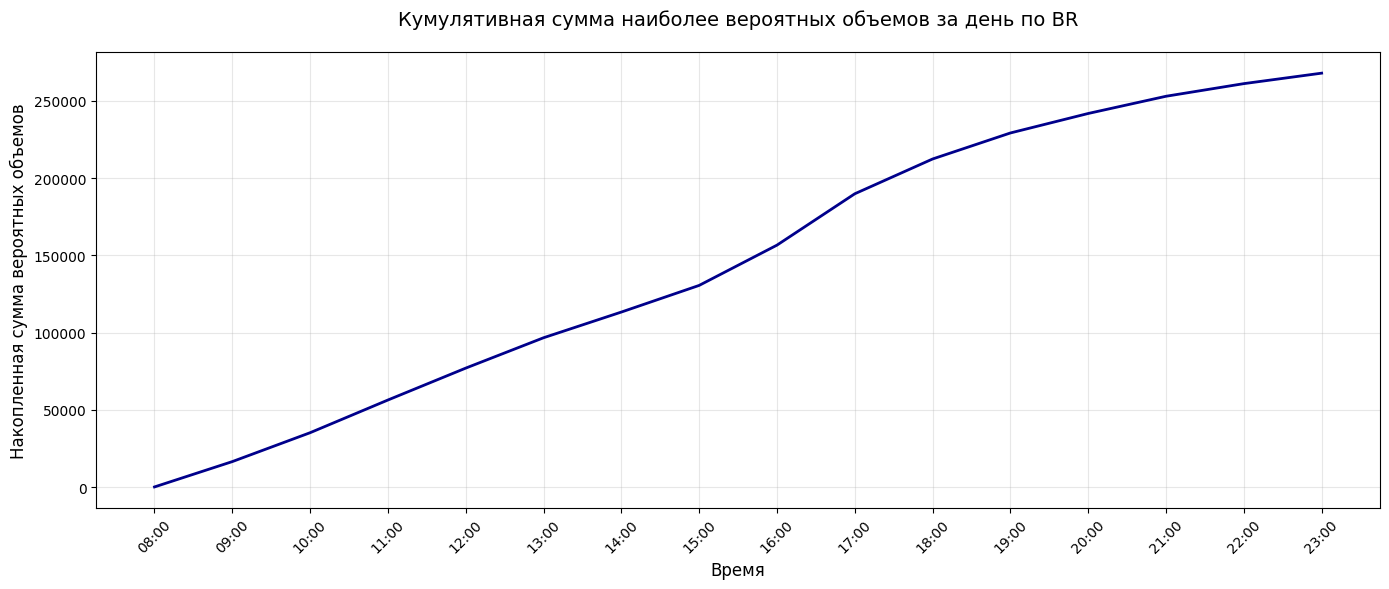

Примеры значений time: ['08:00:00', '09:00:00', '10:00:00', '11:00:00', '12:00:00']
Тип данных time: <class 'str'>


In [21]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

minute_prob_volumes = []
minute_times = [] 

for minute in sorted(df_volume_asset['time'].unique()):
    minute_data = df_volume_asset[df_volume_asset['time'] == minute]['volume']
    if len(minute_data) > 1:
        kde = stats.gaussian_kde(minute_data)
        x_grid = np.linspace(minute_data.min(), minute_data.max(), 100)
        minute_prob_volumes.append(x_grid[np.argmax(kde(x_grid))])
        minute_times.append(minute) 


cumulative = np.cumsum(minute_prob_volumes)

hour_labels = []
hour_positions = []

if all(isinstance(t, (int, np.integer)) for t in minute_times):
    for i, minute in enumerate(minute_times):
        hours = minute // 60
        mins = minute % 60

        if mins == 0:
            hour_positions.append(i)
            hour_labels.append(f"{hours:02d}:00")

elif all(isinstance(t, str) and ':' in t for t in minute_times):
    previous_hour = None
    for i, time_str in enumerate(minute_times):
        hour_part = time_str.split(':')[0]

        if hour_part != previous_hour:
            hour_positions.append(i)
            hour_labels.append(f"{hour_part}:00")
            previous_hour = hour_part

# 4. График
plt.figure(figsize=(14, 6))
plt.plot(range(len(cumulative)), cumulative, linewidth=2, color='darkblue')

if hour_positions:
    plt.xticks(hour_positions, hour_labels, rotation=45)
else:
    step = max(1, len(cumulative) // 10)
    plt.xticks(range(0, len(cumulative), step), 
               [f"Точка {i}" for i in range(0, len(cumulative), step)], 
               rotation=45)

plt.xlabel('Время', fontsize=12)
plt.ylabel('Накопленная сумма вероятных объемов', fontsize=12)
plt.title(f'Кумулятивная сумма наиболее вероятных объемов за день по {ASSET}', fontsize=14, pad=20)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 5. Посмотрим на формат времени
print(f"Примеры значений time: {minute_times[:5]}")
print(f"Тип данных time: {type(minute_times[0]) if minute_times else 'пусто'}")

In [22]:
print(cumulative)

[1.72333333e+02 1.65720909e+04 3.52659091e+04 5.64301515e+04
 7.70712929e+04 9.67187273e+04 1.13349455e+05 1.30597535e+05
 1.56660202e+05 1.89895838e+05 2.12411172e+05 2.29249202e+05
 2.41862545e+05 2.53006576e+05 2.61175212e+05 2.67959364e+05]


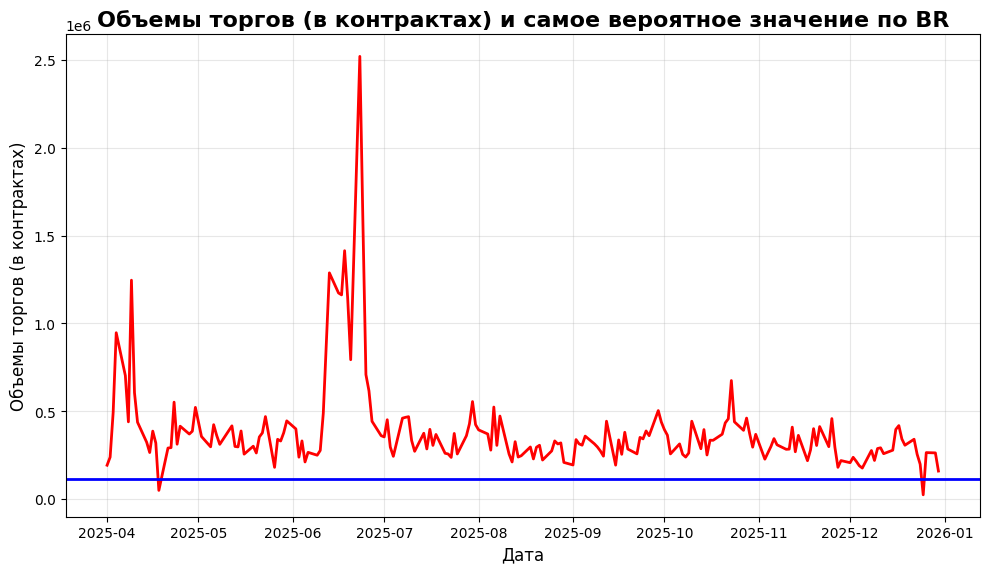

In [23]:
plt.figure(figsize=(10, 6))
plt.plot(df_volume_asset['date'].unique(), df_volume_asset.groupby('date')['volume'].sum(), color='red', linewidth=2, markersize=8)
plt.axhline(y= 1.17087970e+05, color='blue', linewidth=2, label=f"Самое вероятное значение")
# Настройка оформления
plt.title(f'Объемы торгов (в контрактах) и самое вероятное значение по BR', fontsize=16, fontweight='bold')
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Объемы торгов (в контрактах)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Показать график
plt.show()

# Как изменялась расторговка нового актива 

In [24]:
df_volume_10 = pd.read_csv('volume_10.csv')


In [25]:
df_volume_10['date'] = df_volume_10['begin'].str.split(' ').str[0]
df_volume_10['time'] = df_volume_10['begin'].str.split(' ').str[1]
df_volume_10['date'] = pd.to_datetime(df_volume_10['date'])
df_volume_10 = df_volume_10[df_volume_10['date'].dt.dayofweek < 5].copy()
df_volume_ts = df_volume_10[df_volume_10['ASSETCODE'] == 'XIA']
df_volume_ts_before = df_volume_ts[df_volume_ts['date'] < '2025-10-01']
df_volume_ts_after = df_volume_ts[df_volume_ts['date'] >= '2025-10-01']
df_volume_ts_after

,ASSETCODE,begin,volume,NEW_COLUMN,date,time
340244,XIA,2025-10-01 09:00:00,8,international_fond,2025-10-01,09:00:00
340245,XIA,2025-10-01 10:00:00,1,international_fond,2025-10-01,10:00:00
340246,XIA,2025-10-01 12:00:00,1,international_fond,2025-10-01,12:00:00
340247,XIA,2025-10-01 16:00:00,2,international_fond,2025-10-01,16:00:00
340248,XIA,2025-10-01 18:00:00,2,international_fond,2025-10-01,18:00:00
...,...,...,...,...,...,...
340841,XIA,2025-12-30 09:00:00,27,international_fond,2025-12-30,09:00:00
340842,XIA,2025-12-30 10:00:00,4,international_fond,2025-12-30,10:00:00
340843,XIA,2025-12-30 11:00:00,7,international_fond,2025-12-30,11:00:00
340844,XIA,2025-12-30 15:00:00,4,international_fond,2025-12-30,15:00:00


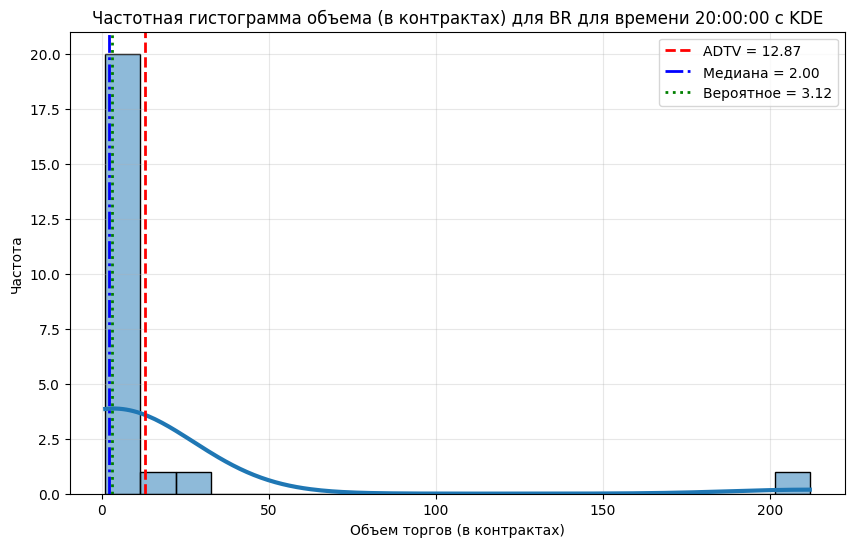

In [26]:
TIME = '20:00:00'
df_time = df_volume_ts_before[df_volume_ts_before['time'] == TIME]

#
adtv_value = df_time['volume'].mean()
median_value = df_time['volume'].median()

plt.figure(figsize=(10, 6))
ax = sns.histplot(data=df_time, x='volume', kde=True, bins=20, 
                  line_kws={'linewidth': 3, 'color': 'red'})

kde_line = ax.lines[0]  
x_kde = kde_line.get_xdata()
y_kde = kde_line.get_ydata()
peak_value = x_kde[y_kde.argmax()]  

plt.title(f'Частотная гистограмма объема (в контрактах) для {ASSET} для времени {TIME} с KDE')

plt.axvline(x=adtv_value, color='red', linestyle='--', linewidth=2, 
            label=f'ADTV = {adtv_value:.2f}')
plt.axvline(x=median_value, color='blue', linestyle='-.', linewidth=2, 
            label=f'Медиана = {median_value:.2f}')
plt.axvline(x=peak_value, color='green', linestyle=':', linewidth=2, 
            label=f'Вероятное = {peak_value:.2f}')

plt.xlabel('Объем торгов (в контрактах)')
plt.ylabel('Частота')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

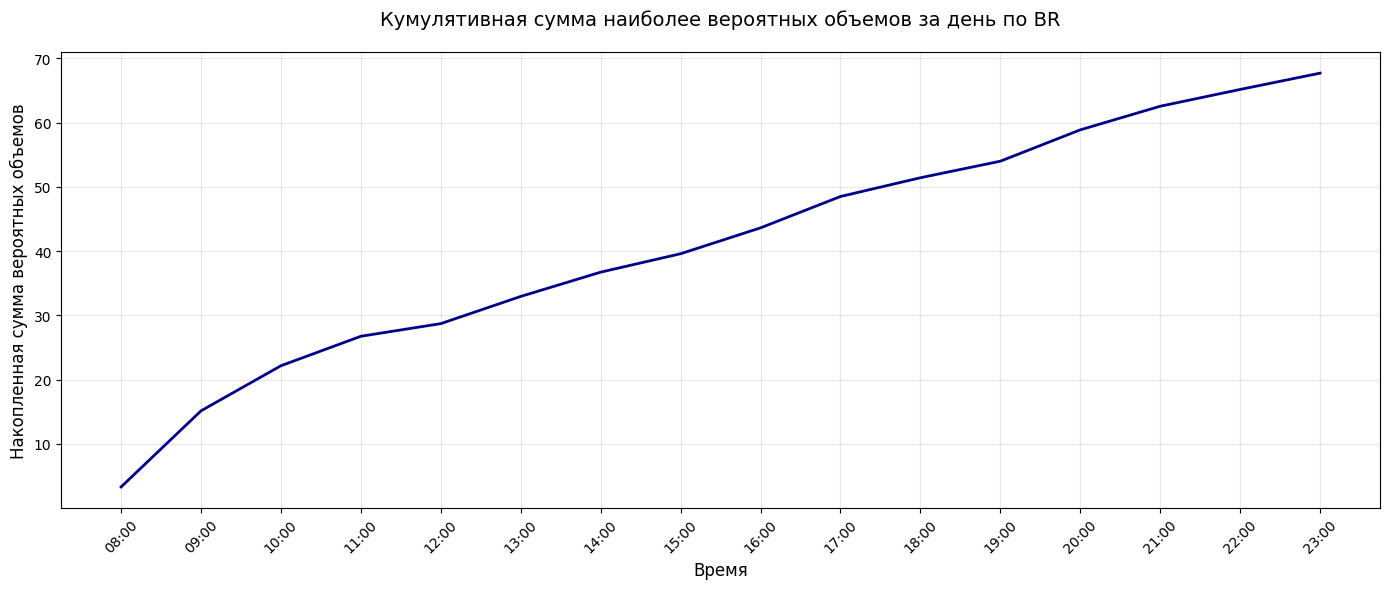

Примеры значений time: ['08:00:00', '09:00:00', '10:00:00', '11:00:00', '12:00:00']
Тип данных time: <class 'str'>


In [27]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

minute_prob_volumes = []
minute_times = [] 

for minute in sorted(df_volume_ts_after['time'].unique()):
    minute_data = df_volume_ts_after[df_volume_ts_after['time'] == minute]['volume']
    if len(minute_data) > 1:
        kde = stats.gaussian_kde(minute_data)
        x_grid = np.linspace(minute_data.min(), minute_data.max(), 100)
        minute_prob_volumes.append(x_grid[np.argmax(kde(x_grid))])
        minute_times.append(minute) 


cumulative = np.cumsum(minute_prob_volumes)

hour_labels = []
hour_positions = []

if all(isinstance(t, (int, np.integer)) for t in minute_times):
    for i, minute in enumerate(minute_times):
        hours = minute // 60
        mins = minute % 60

        if mins == 0:
            hour_positions.append(i)
            hour_labels.append(f"{hours:02d}:00")

elif all(isinstance(t, str) and ':' in t for t in minute_times):
    previous_hour = None
    for i, time_str in enumerate(minute_times):
        hour_part = time_str.split(':')[0]

        if hour_part != previous_hour:
            hour_positions.append(i)
            hour_labels.append(f"{hour_part}:00")
            previous_hour = hour_part

# 4. График
plt.figure(figsize=(14, 6))
plt.plot(range(len(cumulative)), cumulative, linewidth=2, color='darkblue')

if hour_positions:
    plt.xticks(hour_positions, hour_labels, rotation=45)
else:
    # Если не получилось определить часы, просто покажем каждую N-ю точку
    step = max(1, len(cumulative) // 10)
    plt.xticks(range(0, len(cumulative), step), 
               [f"Точка {i}" for i in range(0, len(cumulative), step)], 
               rotation=45)

plt.xlabel('Время', fontsize=12)
plt.ylabel('Накопленная сумма вероятных объемов', fontsize=12)
plt.title(f'Кумулятивная сумма наиболее вероятных объемов за день по {ASSET}', fontsize=14, pad=20)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 5. Посмотрим на формат времени
print(f"Примеры значений time: {minute_times[:5]}")
print(f"Тип данных time: {type(minute_times[0]) if minute_times else 'пусто'}")